In [11]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import random
import os

In [13]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [14]:
import os
import pandas as pd

coca_prepared = (
    "/content/drive/MyDrive/AI_Medical/COCA/coca_prepared"
)

splits_dir = os.path.join(
    coca_prepared,
    "splits"
)

train_df = pd.read_csv(
    os.path.join(splits_dir, "train.csv")
)

val_df = pd.read_csv(
    os.path.join(splits_dir, "validation.csv")
)

test_df = pd.read_csv(
    os.path.join(splits_dir, "test.csv")
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2588
Validation: 555
Test: 528


In [15]:
class COCACalciumDataset(Dataset):

    def __init__(
        self,
        dataframe,
        images_dir,
        masks_dir,
        image_size=256,
        augment=False
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_size = image_size

        self.augment = augment

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self,index):

        row = self.dataframe.iloc[index]

        filename = row["Filename"]

        image = np.load(
            os.path.join(images_dir,filename)
        ).astype(np.float32)

        mask = np.load(
            os.path.join(masks_dir,filename)
        ).astype(np.float32)

        image = np.clip(image,-200,1000)
        image = (image+200)/1200

        mask = (mask>0).astype(np.float32)

        # ---------- Data Augmentation ----------

        if self.augment:

            if random.random()<0.5:

                image=np.fliplr(image).copy()
                mask=np.fliplr(mask).copy()

            if random.random()<0.5:

                image=np.flipud(image).copy()
                mask=np.flipud(mask).copy()

            k=random.randint(0,3)

            image=np.rot90(image,k).copy()
            mask=np.rot90(mask,k).copy()

        image=torch.from_numpy(image).float().unsqueeze(0)

        mask=torch.from_numpy(mask).float().unsqueeze(0)

        image=F.interpolate(
            image.unsqueeze(0),
            size=(256,256),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        mask=F.interpolate(
            mask.unsqueeze(0),
            size=(256,256),
            mode="nearest"
        ).squeeze(0)

        return image,mask

In [16]:
# Paths
images_dir = os.path.join(coca_prepared, "images")
masks_dir = os.path.join(coca_prepared, "masks")

# Create training dataset with augmentation
train_dataset = COCACalciumDataset(
    dataframe=train_df,
    images_dir=images_dir,
    masks_dir=masks_dir,
    image_size=256,
    augment=True
)

print("Training samples:", len(train_dataset))

Training samples: 2588


In [17]:
import os

coca_prepared = "/content/drive/MyDrive/AI_Medical/COCA/coca_prepared"

week5_output = os.path.join(
    coca_prepared,
    "week5_results"
)

os.makedirs(
    week5_output,
    exist_ok=True
)

print("Week 5 folder:")
print(week5_output)

print("Exists:", os.path.exists(week5_output))

Week 5 folder:
/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week5_results
Exists: True


In [18]:
image, mask = train_dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image range:", image.min().item(), "to", image.max().item())
print("Mask values:", torch.unique(mask))

Image shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Image range: 0.0 to 0.9054166674613953
Mask values: tensor([0., 1.])


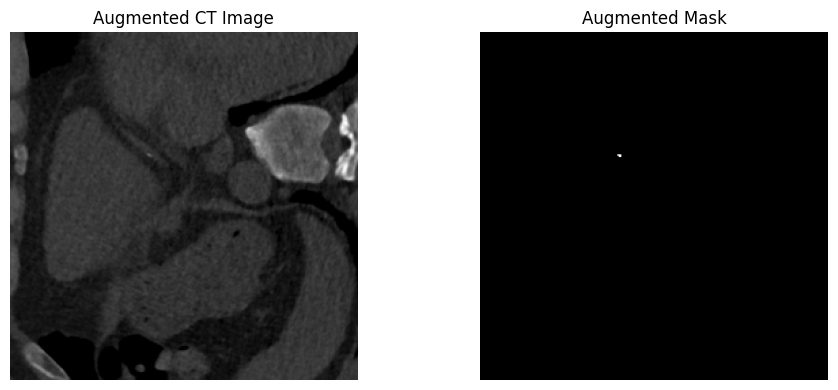

Saved to: /content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week5_results/augmentation_example.png
File exists: True


In [19]:
import matplotlib.pyplot as plt

image_np = image.squeeze().numpy()
mask_np = mask.squeeze().numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_np, cmap="gray")
plt.title("Augmented CT Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_np, cmap="gray")
plt.title("Augmented Mask")
plt.axis("off")

preview_path = os.path.join(
    week5_output,
    "augmentation_example.png"
)

plt.tight_layout()
plt.savefig(
    preview_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved to:", preview_path)
print("File exists:", os.path.exists(preview_path))

In [20]:
# Build DataLoader
train_dataset = COCACalciumDataset(
    dataframe=train_df,
    images_dir=images_dir,
    masks_dir=masks_dir,
    augment=True
)

val_dataset = COCACalciumDataset(
    dataframe=val_df,
    images_dir=images_dir,
    masks_dir=masks_dir,
    augment=False
)

test_dataset = COCACalciumDataset(
    dataframe=test_df,
    images_dir=images_dir,
    masks_dir=masks_dir,
    augment=False
)

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 647
Validation batches: 139
Test batches: 132


In [22]:
# Check one batch
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks :", masks.shape)

Images: torch.Size([4, 1, 256, 256])
Masks : torch.Size([4, 1, 256, 256])


In [23]:
import os

model_path = os.path.join(
    coca_prepared,
    "week3_results",
    "best_unet_model.pth"
)

print(model_path)
print("Exists:", os.path.exists(model_path))

/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week3_results/best_unet_model.pth
Exists: True


In [24]:
# Define the U-Net building block
class DoubleConv(nn.Module):

    def __init__(
        self,
        input_channels,
        output_channels
    ):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(
                input_channels,
                output_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(
                output_channels
            ),
            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                output_channels,
                output_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(
                output_channels
            ),
            nn.ReLU(
                inplace=True
            )
        )

    def forward(self, x):
        return self.layers(x)

In [25]:
# Define UNet
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder1 = DoubleConv(
            1,
            32
        )

        self.encoder2 = DoubleConv(
            32,
            64
        )

        self.encoder3 = DoubleConv(
            64,
            128
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2
        )

        # Bottleneck
        self.bottleneck = DoubleConv(
            128,
            256
        )

        # Decoder
        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.decoder3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.decoder2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.decoder1 = DoubleConv(
            64,
            32
        )

        self.output_layer = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

    def forward(self, x):

        encoder1 = self.encoder1(x)

        encoder2 = self.encoder2(
            self.pool(encoder1)
        )

        encoder3 = self.encoder3(
            self.pool(encoder2)
        )

        bottleneck = self.bottleneck(
            self.pool(encoder3)
        )

        decoder3 = self.up3(
            bottleneck
        )

        decoder3 = torch.cat(
            [decoder3, encoder3],
            dim=1
        )

        decoder3 = self.decoder3(
            decoder3
        )

        decoder2 = self.up2(
            decoder3
        )

        decoder2 = torch.cat(
            [decoder2, encoder2],
            dim=1
        )

        decoder2 = self.decoder2(
            decoder2
        )

        decoder1 = self.up1(
            decoder2
        )

        decoder1 = torch.cat(
            [decoder1, encoder1],
            dim=1
        )

        decoder1 = self.decoder1(
            decoder1
        )

        return self.output_layer(
            decoder1
        )

In [26]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = UNet()

model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

model.to(device)

print("Week 3 model loaded successfully!")

Week 3 model loaded successfully!


In [27]:
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape: ", images.shape)
print("Mask shape:  ", masks.shape)
print("Output shape:", outputs.shape)

Input shape:  torch.Size([4, 1, 256, 256])
Mask shape:   torch.Size([4, 1, 256, 256])
Output shape: torch.Size([4, 1, 256, 256])


In [6]:
best_model_path = os.path.join(
    week5_output,
    "best_week5_model.pth"
)

print("Model exists:", os.path.exists(best_model_path))

if os.path.exists(best_model_path):
    size_mb = os.path.getsize(best_model_path) / (1024 ** 2)
    print(f"Model size: {size_mb:.2f} MB")

Model exists: True
Model size: 7.40 MB


In [38]:
num_epochs = 20

best_model_path = os.path.join(
    week5_output,
    "best_week5_model.pth"
)

for epoch in range(num_epochs):

    ############################
    # Training
    ############################
    model.train()

    train_loss = 0
    train_dice = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = bce_loss(outputs, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        intersection = (preds * masks).sum()

        dice = (
            (2 * intersection + 1e-6)
            /
            (preds.sum() + masks.sum() + 1e-6)
        )

        train_dice += dice.item()

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    ############################
    # Validation
    ############################
    model.eval()

    val_loss = 0
    val_dice = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = bce_loss(outputs, masks)

            val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            intersection = (preds * masks).sum()

            dice = (
                (2 * intersection + 1e-6)
                /
                (preds.sum() + masks.sum() + 1e-6)
            )

            val_dice += dice.item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)

    ############################
    # Save history
    ############################

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_dices.append(train_dice)
    val_dices.append(val_dice)

    ############################
    # Save best model
    ############################

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("Best model saved.")

    ############################
    # Print progress
    ############################

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Dice: {train_dice:.4f} | "
        f"Val Dice: {val_dice:.4f}"
    )

KeyboardInterrupt: 

In [29]:
import os

coca_prepared = "/content/drive/MyDrive/AI_Medical/COCA/coca_prepared"

week5_output = os.path.join(
    coca_prepared,
    "week5_results"
)

print("Folder exists:", os.path.exists(week5_output))
print("Folder contents:", os.listdir(week5_output))

Folder exists: True
Folder contents: ['augmentation_example.png', 'best_week5_model.pth']


In [30]:
import os
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

best_model_path = os.path.join(
    week5_output,
    "best_week5_model.pth"
)

print("Model exists:", os.path.exists(best_model_path))

model = UNet()

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.to(device)
model.eval()

print("Week 5 model loaded successfully!")

Model exists: True
Week 5 model loaded successfully!


In [31]:
all_dice_scores = []
all_iou_scores = []

model.eval()

with torch.no_grad():
    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities > 0.5).float()

        for prediction, mask in zip(predictions, masks):

            intersection = (prediction * mask).sum()

            dice = (
                2 * intersection + 1e-6
            ) / (
                prediction.sum() + mask.sum() + 1e-6
            )

            union = (
                prediction.sum()
                + mask.sum()
                - intersection
            )

            iou = (
                intersection + 1e-6
            ) / (
                union + 1e-6
            )

            all_dice_scores.append(dice.item())
            all_iou_scores.append(iou.item())

print("Test images:", len(all_dice_scores))
print("Mean Dice:", sum(all_dice_scores) / len(all_dice_scores))
print("Mean IoU:", sum(all_iou_scores) / len(all_iou_scores))

Test images: 528
Mean Dice: 0.864875622400965
Mean IoU: 0.8179408639750773


In [36]:
import pandas as pd
import os

evaluation_summary = pd.DataFrame({
    "Metric": [
        "Number of test images",
        "Mean Dice",
        "Mean IoU"
    ],
    "Value": [
        len(all_dice_scores),
        sum(all_dice_scores)/len(all_dice_scores),
        sum(all_iou_scores)/len(all_iou_scores)
    ]
})

summary_path = os.path.join(
    week5_output,
    "evaluation_summary.csv"
)

evaluation_summary.to_csv(
    summary_path,
    index=False
)

print(evaluation_summary)

print("\nSaved to:")
print(summary_path)
print("File exists:", os.path.exists(summary_path))

                  Metric       Value
0  Number of test images  528.000000
1              Mean Dice    0.864876
2               Mean IoU    0.817941

Saved to:
/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week5_results/evaluation_summary.csv
File exists: True


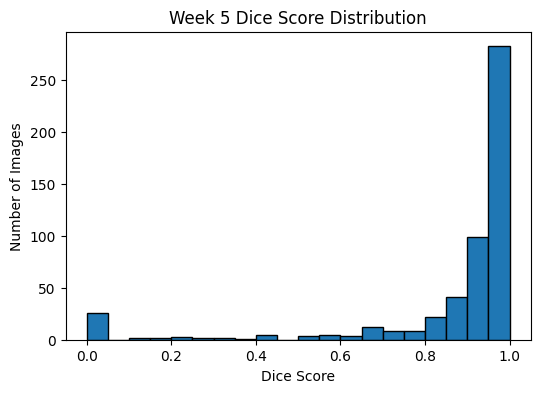


Saved to:
/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week5_results/dice_distribution.png
File exists: True


In [37]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(6,4))

plt.hist(
    all_dice_scores,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Dice Score")
plt.ylabel("Number of Images")
plt.title("Week 5 Dice Score Distribution")

dice_path = os.path.join(
    week5_output,
    "dice_distribution.png"
)

plt.savefig(
    dice_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved to:")
print(dice_path)
print("File exists:", os.path.exists(dice_path))

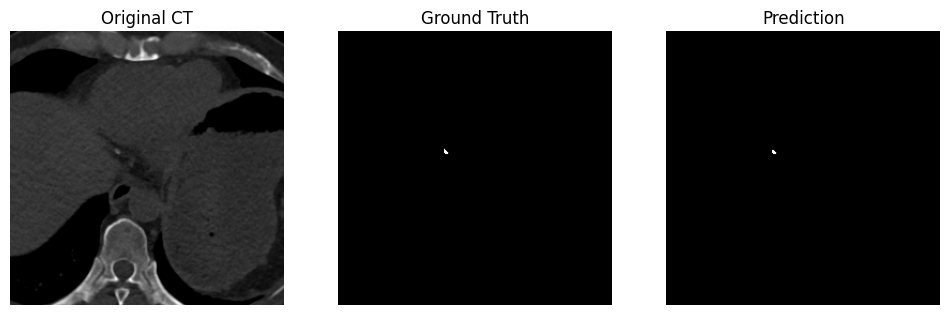


Saved to:
/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week5_results/prediction_example.png
File exists: True


In [38]:
# Prediction example
import matplotlib.pyplot as plt
import os

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)

predictions = (torch.sigmoid(outputs) > 0.5).float()

image = images[0,0].cpu()
mask = masks[0,0].cpu()
prediction = predictions[0,0].cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image, cmap="gray")
plt.title("Original CT")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(prediction, cmap="gray")
plt.title("Prediction")
plt.axis("off")

prediction_path = os.path.join(
    week5_output,
    "prediction_example.png"
)

plt.savefig(
    prediction_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved to:")
print(prediction_path)
print("File exists:", os.path.exists(prediction_path))